In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os
import sys

In [3]:
df_targets = pd.read_csv('../dataset/y_train_hCIvDMj.csv')
print(len(df_targets))

4400


<Axes: >

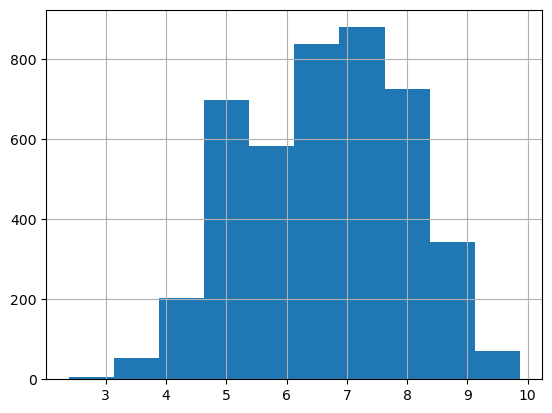

In [4]:
df_targets['y'].hist()

In [5]:

results_df_supermix = pd.read_csv('../results/run_010_mor_rdk_scalars_search_logs.csv')
results_df_mor_rdk = pd.read_csv('../results/run_007_mor_rdk_search_logs.csv')
results_df_mor = pd.read_csv('../results/run_004_morgan_search_logs.csv')

In [6]:
print(results_df_mor_rdk[results_df_mor_rdk['score']==results_df_mor_rdk['score'].min()])

    Unnamed: 0  max_depth  learning_rate  n_estimators  reg_lambda  \
11          11         15       0.014069          2022        10.0   

    feature_fraction  num_leaves     score       time  
11          0.258216         474  0.544652  61.347232  


In [7]:
print(results_df_mor[results_df_mor['score']==results_df_mor['score'].min()])

   Unnamed: 0  max_depth  learning_rate  n_estimators  reg_lambda  \
0           0         39       0.013712          3802    0.021371   

   feature_fraction  num_leaves     score      time  
0          0.237731         744  0.566073  31.18474  


In [8]:
print(results_df_supermix[results_df_supermix['score']==results_df_supermix['score'].min()])

    Unnamed: 0  max_depth  learning_rate  n_estimators  reg_lambda  \
47          47         21       0.008195          5000        0.01   

    feature_fraction  num_leaves     score        time  
47               0.5         300  0.549649  208.574578  


# Analysis of the results of the hyperparameter search

The concatenation of multiple fingerprints has given some improvement on the results, but not a lot. It seems that by making the fingerprints longer we are just adding noise to the dataset for the model.

Still, there is a good sign: the number of estimators is not hitting the end of the allowed range, which means that there is some "signal sweet spot" being hit

In [9]:
# We will load now the optimum model from the mor+rdkit+scalar paramters run:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from pIC50_predictor.model import pIC50Predictor, find_best_params, OptimizerCallback
best_mixed_model = joblib.load('../models/run_010_mor_rdk_scalars_optimum_trained.joblib')

In [10]:
best_mixed_model.model.get_params

<bound method LGBMModel.get_params of LGBMRegressor(feature_fraction=0.5, learning_rate=0.008195307829370857,
              max_depth=np.int64(21), n_estimators=np.int64(5000),
              num_leaves=np.int64(300), random_state=33, reg_lambda=0.01,
              verbose=-1)>

np.int32(29430)

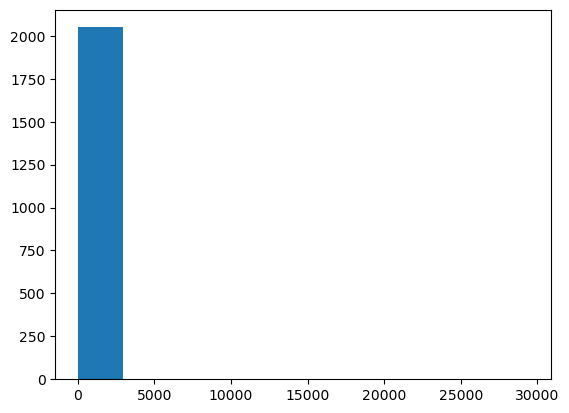

In [11]:
importances = best_mixed_model.model.feature_importances_
plt.hist(importances)
max(importances)

In [12]:
feature_importance_df = pd.DataFrame({'feature_index': range(len(importances)),'importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

print(feature_importance_df.head(10))


   feature_index  importance
0           2049       29430
1           2048       27842
2           2052       13271
3           2051        2726
4           2050        1667
5             64        1450
6            175        1262
7            843        1252
8            184        1170
9            389        1102


In [13]:
a = pd.DataFrame({'feature_index':range(len(importances)),'importance':importances})
a.sort_values(by='importance',ascending=False)

,feature_index,importance
2049,2049,29430
2048,2048,27842
2052,2052,13271
2051,2051,2726
2050,2050,1667
...,...,...
765,765,0
1127,1127,0
22,22,0
756,756,0


In [ ]:
# Now, load replicas of the morgan+rdkit+scalar fingerprint runs, get their importances and average them. Indices:13, 14, 15:
importance_ratings = []
for id in range(13,17):
    opt_model = joblib.load(f'../models/run_0{id}_mor_rdk_scalars_optimum_trained.joblib')
    imps = opt_model.model.feature_importances_
    imp_df = pd.DataFrame({'feature_index': range(len(imps)),'importance': imps})
    imp_df = imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    print(opt_model.model.get_params())


{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.007857850902864168, 'max_depth': np.int64(50), 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': np.int64(5000), 'n_jobs': None, 'num_leaves': np.int64(384), 'objective': None, 'random_state': 33, 'reg_alpha': 0.0, 'reg_lambda': 10.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'feature_fraction': 0.17102784504928667, 'verbose': -1}
      feature_index  importance
0              2048       36360
1              2049       32575
2              2052       26501
3              2051        7339
4              2050        4592
...             ...         ...
2048             71           0
2049            614           0
2050            372           0
2051            374           0
2052             48           0

[2053 rows x 2 columns]
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0

In [18]:
n_top_features = 100